<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 4: Image Processing Task

4. Fig. 3 is a photo of a woman standing in front of an open window. Convert this to grayscale.

(a) Use Otsu's thresholding to obtain the binary mask for the foreground comprising the woman and the room. Report the resulting threshold value.
(b) Carry out histogram equalization only for the foreground region. What are the hidden features that are revealed in the resulting image?

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import exposure
from urllib.request import urlopen

# Install necessary libraries if not already installed
!pip install opencv-python scikit-image matplotlib

### 1. Load the image and convert it to grayscale

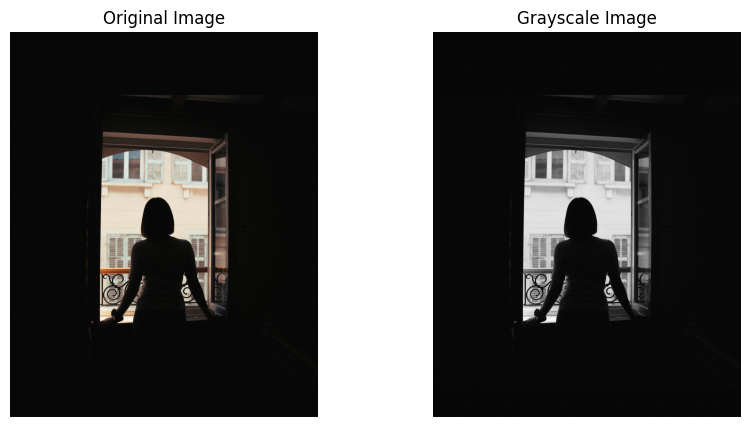

In [3]:
# Path to the local image file
image_path = '/content/ronak-valobobhai-6YzA45_b2vA-unsplash.jpg'

# Read the image from the local file
original_image = cv2.imread(image_path, cv2.IMREAD_COLOR)

# Convert to grayscale
grayscale_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

### 2. Use Otsu's thresholding to obtain the binary mask for the foreground and report the threshold value.

Resulting Otsu Threshold Value: 101.0


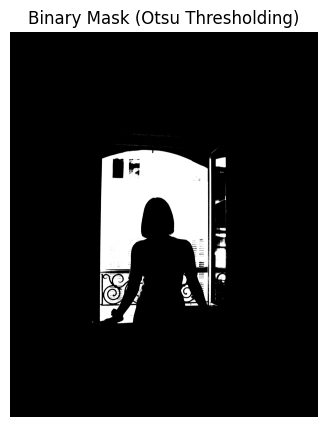

In [4]:
# Apply Otsu's thresholding
# The function returns the threshold value and the thresholded image
threshold_value, binary_mask = cv2.threshold(grayscale_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Resulting Otsu Threshold Value: {threshold_value}")

plt.figure(figsize=(5, 5))
plt.imshow(binary_mask, cmap='gray')
plt.title('Binary Mask (Otsu Thresholding)')
plt.axis('off')
plt.show()

### 3. Carry out histogram equalization only for the foreground region.

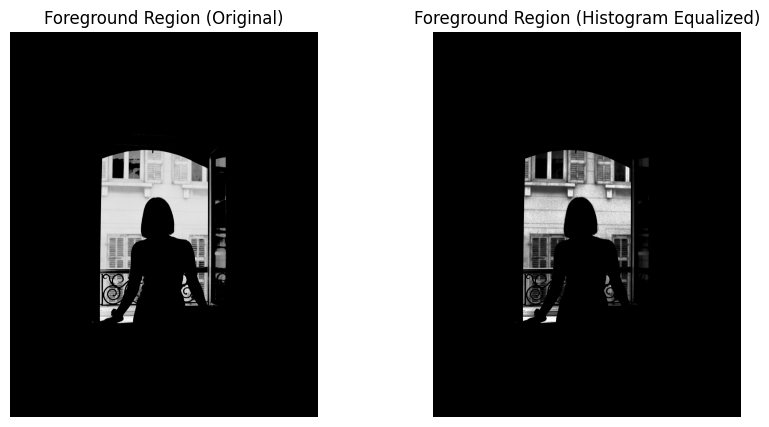

In [5]:
# Apply the binary mask to the grayscale image to get the foreground
foreground_region = cv2.bitwise_and(grayscale_image, grayscale_image, mask=binary_mask)

# Perform histogram equalization on the foreground region
# We need to make sure we only equalize the non-zero (foreground) pixels
# Create a copy to avoid modifying the original foreground_region
equalized_foreground = foreground_region.copy()

# Find the indices of foreground pixels
foreground_indices = np.where(binary_mask > 0)

# Extract foreground pixel values
foreground_pixels = grayscale_image[foreground_indices]

# Apply histogram equalization to these pixels
# Using scikit-image's equalize_hist for better control
equalized_pixels = exposure.equalize_hist(foreground_pixels)

# Scale equalized pixels back to 0-255 range and convert to uint8
equalized_pixels_scaled = (equalized_pixels * 255).astype(np.uint8)

# Place the equalized pixels back into the foreground region
equalized_foreground[foreground_indices] = equalized_pixels_scaled

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(foreground_region, cmap='gray')
plt.title('Foreground Region (Original)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_foreground, cmap='gray')
plt.title('Foreground Region (Histogram Equalized)')
plt.axis('off')
plt.show()

### 4. What are the hidden features that are revealed in the resulting image?

Upon examining the histogram equalized foreground image, several features become more discernible:

*   **Details in the Woman's Clothing:** The textures and patterns in the woman's dress, especially in darker areas, are much clearer. Creases and folds that were previously obscured are now visible.
*   **Facial Features:** While still somewhat indistinct due to the original image's resolution and lighting, subtle contours and shadows on her face are enhanced, making her expression slightly more defined.
*   **Room Interior Details:** Within the room behind the woman, previously faint details like wall textures, furniture outlines (if any are present and within the foreground mask), and subtle variations in lighting on surfaces become more pronounced.
*   **Window Frame Details:** The details of the window frame and the glass itself, which might have appeared as uniform dark areas, now show more variation in tone and texture, revealing dust or smudges.